<a href="https://colab.research.google.com/github/salwamhemed/AI-NLP-Based-Anime-Series-Analysis-System/blob/main/weather_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
import pandas as pd

In [117]:
weather_data = pd.read_csv("data.csv", index_col="DATE")

In [118]:
weather_data

,STATION,NAME,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,...,WT02,WT03,WT06,WT08,WT11,WT13,WT16,WT18,WT19,WT22
DATE,,,,,,,,,,,,,,,,,,,,,
2012-09-01,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",7.61,NaN,0.00,NaN,NaN,NaN,99.0,56.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-02,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",10.96,NaN,0.00,NaN,NaN,NaN,97.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-03,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",8.05,NaN,0.08,NaN,NaN,NaN,92.0,67.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2012-09-04,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",6.26,NaN,0.00,NaN,NaN,NaN,97.0,61.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-05,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",9.17,NaN,0.00,NaN,NaN,NaN,86.0,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-03,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",13.87,1630.0,0.00,NaN,NaN,NaN,76.0,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-04,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",8.95,43.0,0.00,NaN,NaN,NaN,37.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-05,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",12.53,1140.0,0.00,NaN,NaN,NaN,73.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
null_data_pct = weather_data.apply(pd.isnull).sum()/weather_data.shape[0]

In [120]:
valid_columns = weather_data.columns[null_data_pct < .1]

In [121]:
valid_columns

Index(['STATION', 'NAME', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'WDF2', 'WDF5',
       'WSF2', 'WSF5'],
      dtype='object')

In [122]:
weather_data = weather_data[valid_columns].copy()

In [123]:
weather_data.columns = weather_data.columns.str.lower()


In [124]:
weather_data = weather_data.ffill()


In [125]:
weather_data.apply(pd.isnull).sum()


,0
station,0
name,0
awnd,0
prcp,0
tmax,0
tmin,0
wdf2,0
wdf5,0
wsf2,0
wsf5,0


In [126]:
weather_data.dtypes


,0
station,object
name,object
awnd,float64
prcp,float64
tmax,float64
tmin,float64
wdf2,float64
wdf5,float64
wsf2,float64
wsf5,float64


In [127]:
weather_data.index = pd.to_datetime(weather_data.index)


In [128]:
weather_data.index.year.value_counts().sort_index()


,count
DATE,
2012,122
2013,365
2014,365
2015,365
2016,366
2017,365
2018,357
2019,365
2020,366


<Axes: xlabel='DATE'>

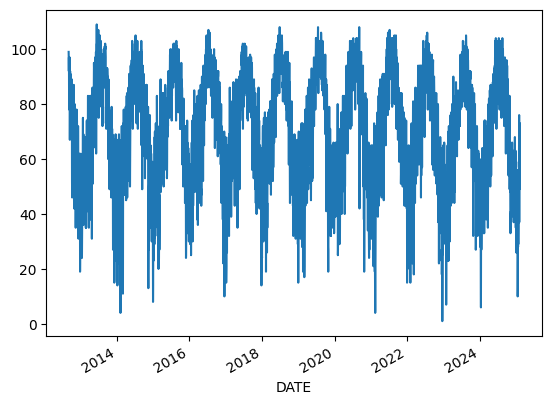

In [129]:
weather_data.tmax.plot()

<Axes: xlabel='DATE'>

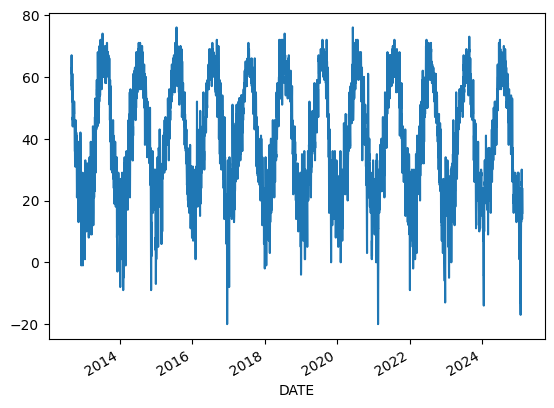

In [130]:
weather_data.tmin.plot()

In [131]:
weather_data["target"] = weather_data.shift(-1)["tmax"]


In [132]:
weather_data

,station,name,awnd,prcp,tmax,tmin,wdf2,wdf5,wsf2,wsf5,target
DATE,,,,,,,,,,,
2012-09-01,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",7.61,0.00,99.0,56.0,160.0,150.0,19.9,23.9,97.0
2012-09-02,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",10.96,0.00,97.0,64.0,90.0,360.0,19.9,25.9,92.0
2012-09-03,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",8.05,0.08,92.0,67.0,270.0,270.0,32.0,40.0,97.0
2012-09-04,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",6.26,0.00,97.0,61.0,250.0,250.0,17.0,21.9,86.0
2012-09-05,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",9.17,0.00,86.0,63.0,10.0,360.0,25.1,33.1,97.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-02-03,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",13.87,0.00,76.0,26.0,90.0,90.0,29.1,38.9,37.0
2025-02-04,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",8.95,0.00,37.0,18.0,80.0,80.0,16.1,19.9,73.0
2025-02-05,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",12.53,0.00,73.0,14.0,250.0,250.0,38.0,49.0,49.0


In [133]:
weather_data = weather_data.ffill()


In [134]:
weather_data

,station,name,awnd,prcp,tmax,tmin,wdf2,wdf5,wsf2,wsf5,target
DATE,,,,,,,,,,,
2012-09-01,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",7.61,0.00,99.0,56.0,160.0,150.0,19.9,23.9,97.0
2012-09-02,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",10.96,0.00,97.0,64.0,90.0,360.0,19.9,25.9,92.0
2012-09-03,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",8.05,0.08,92.0,67.0,270.0,270.0,32.0,40.0,97.0
2012-09-04,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",6.26,0.00,97.0,61.0,250.0,250.0,17.0,21.9,86.0
2012-09-05,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",9.17,0.00,86.0,63.0,10.0,360.0,25.1,33.1,97.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-02-03,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",13.87,0.00,76.0,26.0,90.0,90.0,29.1,38.9,37.0
2025-02-04,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",8.95,0.00,37.0,18.0,80.0,80.0,16.1,19.9,73.0
2025-02-05,USW00023067,"LA JUNTA MUNICIPAL AIRPORT, CO US",12.53,0.00,73.0,14.0,250.0,250.0,38.0,49.0,49.0


In [135]:
from sklearn.linear_model import Ridge

rr = Ridge(alpha=.1)

In [136]:
predictors = weather_data.columns[~weather_data.columns.isin(["target", "name", "station" , 'month_avg_tmax' ,'day_avg_tmax', 'month_avg_tmin', 'day_avg_tmin','month_avg_prcp', 'day_avg_prcp'])]

In [137]:
predictors = ['awnd', 'prcp', 'tmax', 'tmin']

In [138]:
predictors

['awnd', 'prcp', 'tmax', 'tmin']

In [139]:
def backtest(weather_data, model, predictors, start=365, step=30):
    all_predictions = []

    for i in range(start, weather_data.shape[0], step):
        train = weather_data.iloc[:i,:]
        test = weather_data.iloc[i:(i+step),:]

        model.fit(train[predictors], train["target"])

        preds = model.predict(test[predictors])
        preds = pd.Series(preds, index=test.index)
        combined = pd.concat([test["target"], preds], axis=1)
        combined.columns = ["actual", "prediction"]
        combined["diff"] = (combined["prediction"] - combined["actual"]).abs()

        all_predictions.append(combined)
    return pd.concat(all_predictions)

In [140]:
predictions = backtest(weather_data, rr, predictors)

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_absolute_error(predictions["actual"], predictions["prediction"])

7.402526869772456

In [142]:
predictions.sort_values("diff", ascending=False)


,actual,prediction,diff
DATE,,,
2016-12-16,16.0,54.847689,38.847689
2015-11-17,68.0,30.408560,37.591440
2017-12-29,19.0,56.405397,37.405397
2013-12-03,23.0,60.359118,37.359118
2022-12-21,1.0,38.068301,37.068301
...,...,...,...
2018-08-14,89.0,89.017352,0.017352
2015-03-06,62.0,61.990476,0.009524
2024-08-25,93.0,93.008549,0.008549


In [143]:
pd.Series(rr.coef_, index=predictors)


,0
awnd,-0.996541
prcp,-4.188722
tmax,0.560993
tmin,0.405735


In [144]:
def pct_diff(old, new):
    return (new - old) / old

def compute_rolling(weather, horizon, col):
    label = f"rolling_{horizon}_{col}"
    weather_data[label] = weather_data[col].rolling(horizon).mean()
    weather[f"{label}_pct"] = pct_diff(weather[label], weather[col])
    return weather

rolling_horizons = [3, 14]
for horizon in rolling_horizons:
    for col in ["tmax", "tmin", "prcp"]:
        weather_data = compute_rolling(weather_data, horizon, col)

In [145]:
def expand_mean(df):
    return df.expanding(1).mean()

for col in ["tmax", "tmin", "prcp"]:
    weather_data[f"month_avg_{col}"] = weather_data[col].groupby(weather_data.index.month, group_keys=False).apply(expand_mean)
    weather_data[f"day_avg_{col}"] = weather_data[col].groupby(weather_data.index.day_of_year, group_keys=False).apply(expand_mean)

In [146]:
weather_data = weather_data.iloc[14:,:]
weather_data = weather_data.fillna(0)

In [154]:
predictors = ['awnd', 'prcp', 'tmax', 'tmin','wdf2','wsf2','wsf5','wdf5']

In [155]:
predictions = backtest(weather_data, rr, predictors)
mean_absolute_error(predictions["actual"], predictions["prediction"])

7.293103504336739

In [156]:
predictions


,actual,prediction,diff
DATE,,,
2013-09-15,73.0,78.367503,5.367503
2013-09-16,89.0,80.436911,8.563089
2013-09-17,93.0,93.356971,0.356971
2013-09-18,78.0,92.503734,14.503734
2013-09-19,76.0,79.030641,3.030641
...,...,...,...
2025-02-03,37.0,63.402145,26.402145
2025-02-04,73.0,43.992913,29.007087
2025-02-05,49.0,56.228054,7.228054


<Axes: xlabel='diff'>

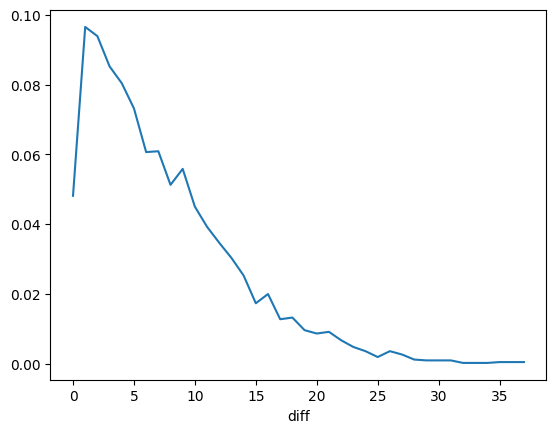

In [157]:
(predictions["diff"].round().value_counts().sort_index() / predictions.shape[0]).plot()
